In [5]:
# Step 0: Install required libraries
!pip install opencv-python-headless matplotlib numpy


In [6]:
# Step 1: Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


In [7]:
# Step 2: Upload your single image
# You will select "traffic signs.jpg" from your computer
uploaded = files.upload()


Saving traffic signs.jpg to traffic signs (1).jpg


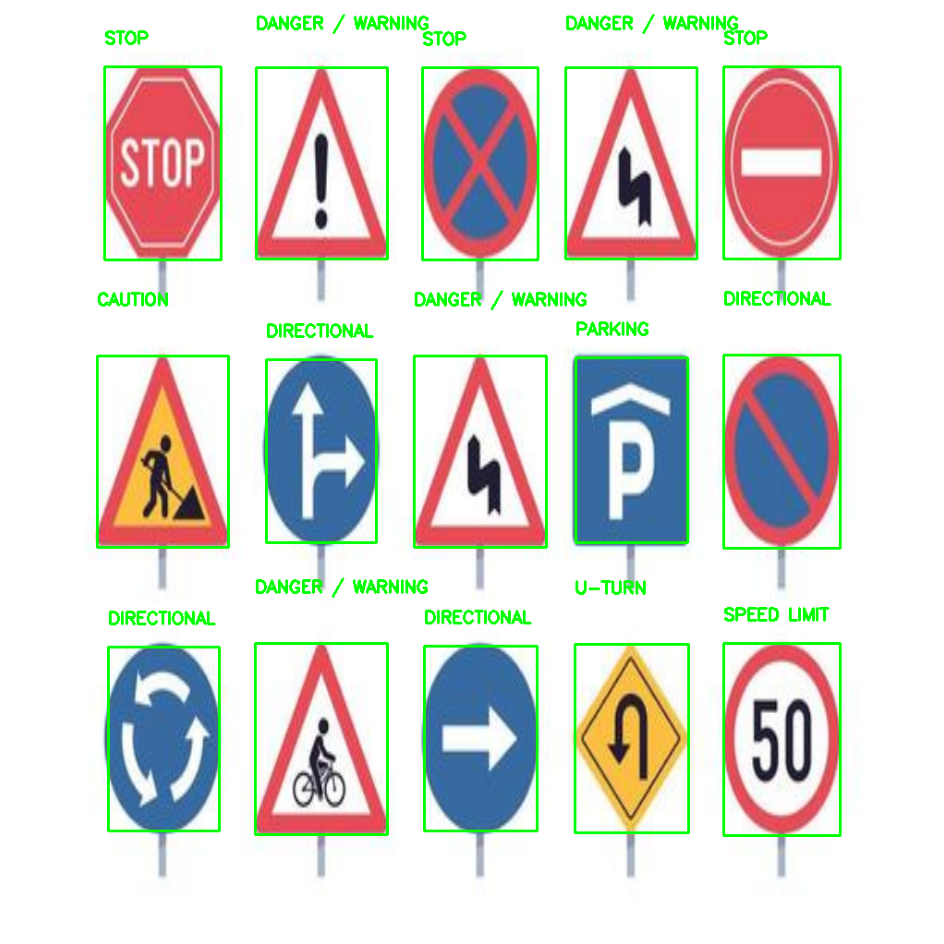

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_traffic_signs(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (1000, 1000))
    orig = img.copy()
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # --- Color Masks ---
    lower_red1, upper_red1 = np.array([0, 70, 50]), np.array([10, 255, 255])
    lower_red2, upper_red2 = np.array([170, 70, 50]), np.array([180, 255, 255])
    mask_red = cv2.inRange(hsv, lower_red1, upper_red1) + cv2.inRange(hsv, lower_red2, upper_red2)

    lower_blue = np.array([100, 150, 50]), np.array([140, 255, 255])
    mask_blue = cv2.inRange(hsv, lower_blue[0], lower_blue[1])

    lower_yellow = np.array([15, 100, 100]), np.array([35, 255, 255])
    mask_yellow = cv2.inRange(hsv, lower_yellow[0], lower_yellow[1])

    lower_white = np.array([180, 180, 180])
    upper_white = np.array([255, 255, 255])
    mask_white = cv2.inRange(img, lower_white, upper_white)

    mask_total = mask_red + mask_blue + mask_yellow
    kernel = np.ones((5,5), np.uint8)
    mask_total = cv2.morphologyEx(mask_total, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask_total, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=lambda c: (cv2.boundingRect(c)[1] // 100, cv2.boundingRect(c)[0]))

    for i, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)
        if area > 1000:
            peri = cv2.arcLength(cnt, True)
            approx = cv2.approxPolyDP(cnt, 0.03 * peri, True)
            num_vertices = len(approx)

            x, y, w, h = cv2.boundingRect(cnt)
            red_px = cv2.countNonZero(mask_red[y:y+h, x:x+w])
            blue_px = cv2.countNonZero(mask_blue[y:y+h, x:x+w])
            yellow_px = cv2.countNonZero(mask_yellow[y:y+h, x:x+w])
            white_px = cv2.countNonZero(mask_white[y:y+h, x:x+w])

            sign_label = "SIGN"

            # --- 1. YELLOW LOGIC (FIXED) ---
            if yellow_px > 500:
                # Diamond shape (usually 4 vertices) is U-TURN
                if num_vertices == 4:
                    sign_label = "U-TURN"
                # Rectangles or other yellow concentrations are CAUTION
                else:
                    sign_label = "CAUTION"

            # --- 2. RED LOGIC (STOP, SPEED LIMIT, DANGER) ---
            elif red_px > blue_px:
                # Circle + White concentration > 15000 is SPEED LIMIT
                if num_vertices > 5 and white_px > 15000:
                    sign_label = "SPEED LIMIT"
                # Octagon/Circle with low white is STOP
                elif num_vertices >= 7 or (num_vertices > 5 and white_px <= 15000):
                    sign_label = "STOP"
                # Triangle/Rectangle is DANGER / WARNING
                elif 3 <= num_vertices <= 4:
                    sign_label = "DANGER / WARNING"

            # --- 3. BLUE LOGIC (DIRECTIONAL, PARKING) ---
            elif blue_px > 500:
                # Exact square/rectangle is PARKING
                if num_vertices == 4:
                    sign_label = "PARKING"
                # Circle/other is DIRECTIONAL
                else:
                    sign_label = "DIRECTIONAL"

            # --- LABEL PLACEMENT (ALWAYS ABOVE) ---
            y_offset = 25 if (i % 2 == 0) else 55
            text_y = y - y_offset
            if text_y < 20: text_y = 20

            cv2.rectangle(orig, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(orig, sign_label, (x, text_y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

detect_traffic_signs('traffic signs.jpg')